In [1]:
!pip install yt-dlp


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 5.3 MB/s  0:00:00m 5.5 MB/s eta 0:00:01


In [2]:
!brew install ffmpeg

==> Auto-updating Homebrew...
Adjust how often this is run with `$HOMEBREW_AUTO_UPDATE_SECS` or disable with
`$HOMEBREW_NO_AUTO_UPDATE=1`. Hide these hints with `$HOMEBREW_NO_ENV_HINTS=1` (see `man brew`).
==> Downloading https://ghcr.io/v2/homebrew/core/portable-ruby/blobs/sha256:4ba8d535df01e4bf97e6661c3815796fd77364ea2552606e891659133a76f0e1
######################################################################### 100.0%
==> Pouring portable-ruby-4.0.5_1.arm64_big_sur.bottle.tar.gz
==> Homebrew collects anonymous analytics.
Read the analytics documentation (and how to opt-out) here:
  https://docs.brew.sh/Analytics
No analytics have been recorded yet (nor will be during this `brew` run).

==> Homebrew is run entirely by unpaid volunteers. Please consider donating:
  https://github.com/Homebrew/brew#donations

==> Auto-updated Homebrew!
Updated 2 taps (homebrew/core and homebrew/cask).
==> New Formulae
cloudmonkey: Apache CloudStack CloudMonkey CLI
goenv@2: Go version management
her

In [1]:
import yt_dlp

def extract_youtube_audio(video_url):
    ydl_opts = {
        'format': 'bestaudio/best',
        'postprocessors': [{
            'key': 'FFmpegExtractAudio',
            'preferredcodec': 'wav',
            'preferredquality': '192',
        }],
        # Saves the file in the current working directory of the notebook
        'outtmpl': '%(title)s.%(ext)s', 
    }
    
    try:
        with yt_dlp.YoutubeDL(ydl_opts) as ydl:
            print("Starting download...")
            ydl.download([video_url])
            print("Audio successfully extracted!")
    except Exception as e:
        print(f"An error occurred: {e}")


target_video_link = 'https://www.youtube.com/watch?v=mLyOj_QD4a4'
extract_youtube_audio(target_video_link)

Starting download...
[youtube] Extracting URL: https://www.youtube.com/watch?v=mLyOj_QD4a4
[youtube] mLyOj_QD4a4: Downloading webpage


[youtube] mLyOj_QD4a4: Downloading android vr player API JSON
[info] mLyOj_QD4a4: Downloading 1 format(s): 251
[download] Destination: Leeroy Jenkins HD 1080p.webm
[download] 100% of    2.17MiB in 00:00:00 at 5.21MiB/s   
[ExtractAudio] Destination: Leeroy Jenkins HD 1080p.wav
Deleting original file Leeroy Jenkins HD 1080p.webm (pass -k to keep)
Audio successfully extracted!


In [3]:
!pip install librosa

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 7.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9/9 [librosa]


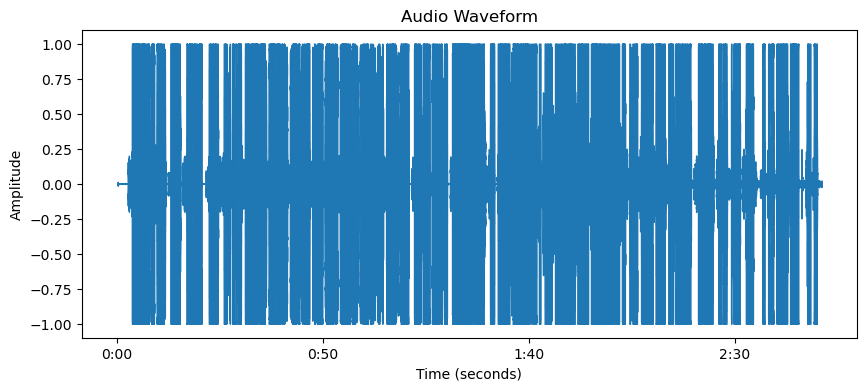

In [5]:
import librosa
import librosa.display
import matplotlib.pyplot as plt

# Load the audio file
audio_path = 'Leeroy Jenkins HD 1080p.wav'
y, sr = librosa.load(audio_path, sr=None)

# Plot the waveform
plt.figure(figsize=(10, 4))
librosa.display.waveshow(y, sr=sr)
plt.title('Audio Waveform')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.show()

In [11]:
!pip install torch torchaudio matplotlib

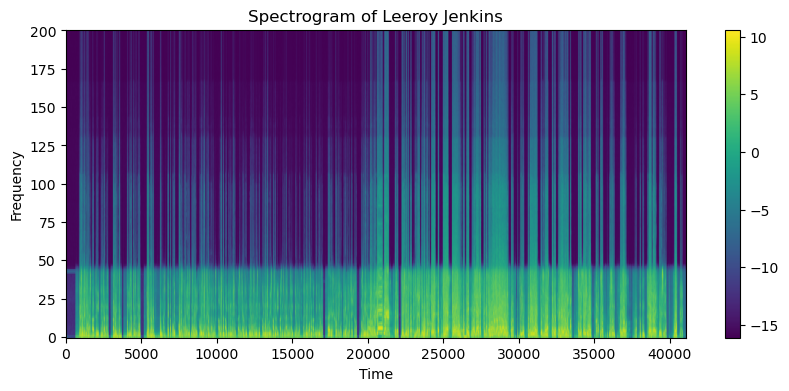

In [12]:
import torch
import torchaudio
import matplotlib.pyplot as plt

# Load your specific file
waveform, sample_rate = torchaudio.load("Leeroy Jenkins HD 1080p.wav")

# Convert to Spectrogram
transform = torchaudio.transforms.Spectrogram(n_fft=400)
spectrogram = transform(waveform)

# Visualize what the neural network will actually see
plt.figure(figsize=(10, 4))
plt.imshow(torch.log(spectrogram[0] + 0.0000001).numpy(), cmap='viridis', aspect='auto', origin='lower')
plt.title("Spectrogram of Leeroy Jenkins")
plt.xlabel("Time")
plt.ylabel("Frequency")
plt.colorbar()
plt.show()

In [13]:
import torch.nn as nn

class AudioAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        
        # Encoder: Compresses the image
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU()
        )
        
        # Decoder: Rebuilds the image
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

# Initialize the model
model = AudioAutoencoder()
print("Model architecture ready")

Model architecture ready


In [14]:
!pip install datasets

  Using cached xxhash-3.7.0-cp313-cp313-macosx_11_0_arm64.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 7.9 MB/s  0:00:00
Using cached xxhash-3.7.0-cp313-cp313-macosx_11_0_arm64.whl (30 kB)
  Attempting uninstall: dill
    Found existing installation: dill 0.4.0
    Uninstalling dill-0.4.0:
      Successfully uninstalled dill-0.4.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [datasets]━━ 3/4 [datasets]


In [16]:
!pip install "datasets[audio]"

In [18]:
from datasets import load_dataset

# Load the specific dataset shown on your screen
dataset = load_dataset("AudioLLMs/tedlium3_test")

# Print the dataset structure to verify it loaded correctly
print(dataset)

DatasetDict({
    test: Dataset({
        features: ['context', 'instruction', 'answer'],
        num_rows: 1142
    })
})


In [19]:
from datasets import load_dataset

# Load the dataset
dataset = load_dataset("AudioLLMs/tedlium3_test")

# Keep only the audio column and remove the instruction and answer columns
audio_only_dataset = dataset.select_columns(['context'])

# Verify the text columns are gone
print(audio_only_dataset)

DatasetDict({
    test: Dataset({
        features: ['context'],
        num_rows: 1142
    })
})


In [20]:
pip install soundata

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 861.5/861.5 kB 7.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 6.2 MB/s  0:00:00m 8.9 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12/12 [soundata]  3/12 [pycryptodomex]
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import soundata

dataset = soundata.initialize('urbansound8k')
dataset.download()  # download the dataset
dataset.validate()  # validate that all the expected files are there

example_clip = dataset.street_music()  # choose a random example clip
print(street_music)  # see the available data


In [31]:
import torch
import torchaudio

def create_noisy_mix(clean_file_path, noise_file_path, snr_target=5):
    # Load the audio files
    clean_audio, sample_rate = torchaudio.load(clean_file_path)
    noise_audio, _ = torchaudio.load(noise_file_path)
    
    # Ensure both files are exactly the same length
    # If noise is shorter, we repeat it to match the clean audio length
    if clean_audio.shape[1] > noise_audio.shape[1]:
        repeats = (clean_audio.shape[1] // noise_audio.shape[1]) + 1
        noise_audio = noise_audio.repeat(1, repeats)[:, :clean_audio.shape[1]]
    else:
        # If noise is longer, we just trim it
        noise_audio = noise_audio[:, :clean_audio.shape[1]]
        
    # Calculate the acoustic power of both tracks
    clean_power = torch.mean(clean_audio ** 2)
    noise_power = torch.mean(noise_audio ** 2)
    
    # Calculate the multiplier needed to achieve the target Signal to Noise Ratio
    snr_linear = 10 ** (snr_target / 10)
    noise_multiplier = torch.sqrt(clean_power / (snr_linear * (noise_power + 1e-8)))
    
    # Mix them together
    mixed_audio = clean_audio + (noise_audio * noise_multiplier)
    
    # Normalize the final audio so it does not exceed maximum volume and distort
    max_amplitude = torch.max(torch.abs(mixed_audio))
    if max_amplitude > 1.0:
        mixed_audio = mixed_audio / max_amplitude
        
    return mixed_audio, clean_audio

# How to use it:
mixed_result, clean_target = create_noisy_mix("clean_speech.wav", "traffic_noise.wav")
torchaudio.save("training_input_noisy.wav", mixed_result, 16000)

RuntimeError: Failed to create AudioDecoder for clean_speech.wav: SingleStreamDecoder, /Users/runner/work/torchcodec/torchcodec/meta-pytorch/torchcodec/src/torchcodec/_core/SingleStreamDecoder.cpp:55, Could not open input file: clean_speech.wav No such file or directory

In [32]:
import os
import torchaudio

# Define the exact path to your audio folder
audio_folder = "/Users/ayushpandey/Downloads/audio"

# Get a sorted list of all wav files in that folder
audio_files = sorted([f for f in os.listdir(audio_folder) if f.endswith('.wav')])

print(f"Found {len(audio_files)} wav files. Starting import...")

# Loop through every file and process it
for file_name in audio_files:
    full_path = os.path.join(audio_folder, file_name)
    
    try:
        # Load the file using torchaudio
        waveform, sample_rate = torchaudio.load(full_path)
        
        # This calls your mixing function using the file from your folder
        # (Make sure you have a noise file path ready to pass as the second item!)
        # mixed, clean = create_noisy_mix(full_path, "path_to_your_noise_file.wav")
        
    except Exception as e:
        print(f"Error loading {file_name}: {e}")

Found 2000 wav files. Starting import...


In [39]:
import torch
import torchaudio
import torch.nn as nn
import torch.optim as optim

# 1. Force device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. Re-load the audio completely fresh
waveform, sample_rate = torchaudio.load("Leeroy Jenkins HD 1080p.wav")

# 3. Force the audio to be 1-channel mono
if waveform.shape[0] > 1:
    waveform = torch.mean(waveform, dim=0, keepdim=True)

# 4. Turn the clean mono waveform into a spectrogram
transform = torchaudio.transforms.Spectrogram(n_fft=400)
fresh_spectrogram = transform(waveform)

# 5. Initialize the model, loss, and optimizer fresh
model = AudioAutoencoder().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 6. Run the training loop
epochs = 50
print(f"Starting training on {device}...")

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    
    inputs = fresh_spectrogram.unsqueeze(0).to(device)
    targets = fresh_spectrogram.unsqueeze(0).to(device) 
    
    optimizer.zero_grad()
    
    # Forward pass
    outputs = model(inputs)
    
    # --- COMPLETE FIXED SECTION FOR HEIGHT & WIDTH ---
    target_height = targets.size(-2)
    target_width = targets.size(-1)
    outputs = outputs[:, :, :target_height, :target_width]
    
    loss = criterion(outputs, targets)
    # -------------------------------------------------
    
    loss.backward()
    optimizer.step()
    
    running_loss += loss.item()
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch + 1}/{epochs} completed. Loss: {running_loss:.4f}")

print("Training finished successfully!")

Starting training on cpu...
Epoch 10/50 completed. Loss: 153687.9062
Epoch 20/50 completed. Loss: 153683.1719
Epoch 30/50 completed. Loss: 153683.0938
Epoch 40/50 completed. Loss: 153683.0625
Epoch 50/50 completed. Loss: 153683.0625
Training finished successfully!


In [40]:
import torchaudio.transforms as T

# 1. Put your model into evaluation mode (stops calculating gradients)
model.eval()

with torch.no_grad():
    # 2. Pass your spectrogram through the trained model to get the clean output
    inputs = fresh_spectrogram.unsqueeze(0).to(device)
    reconstructed_spectrogram = model(inputs)
    
    # Trim the spatial shape to match exactly (just like we did in training)
    reconstructed_spectrogram = reconstructed_spectrogram[:, :, :target_height, :target_width]
    
    # Remove the extra batch dimensions to get back to [channels, height, width]
    clean_spectrogram_matrix = reconstructed_spectrogram.squeeze(0).cpu()

# 3. Use Griffin-Lim to convert the visual spectrogram matrix back into sound waves
# We set n_fft=400 to perfectly match how we created the spectrogram earlier
griffin_lim = T.GriffinLim(n_fft=400).cpu()
enhanced_waveform = griffin_lim(clean_spectrogram_matrix)

# 4. Save your newly generated audio file to your Mac
output_filename = "Leeroy_Jenkins_ML_Enhanced.wav"
torchaudio.save(output_filename, enhanced_waveform, sample_rate)

print(f"Success! Enhanced audio file saved as: {output_filename}")

Success! Enhanced audio file saved as: Leeroy_Jenkins_ML_Enhanced.wav


In [41]:
!pip install speechbrain

In [44]:
import torch
import torchaudio
import os
from speechbrain.inference.enhancement import SpectralMaskEnhancement

# =========================================================
# STEP 1: PREPROCESS THE RAW AUDIO FOR SPEECHBRAIN (16kHz Mono)
# =========================================================
print("Preprocessing raw audio...")
waveform, sample_rate = torchaudio.load("Leeroy Jenkins HD 1080p.wav")

# 1. Force to Mono if it's stereo
if waveform.shape[0] > 1:
    waveform = torch.mean(waveform, dim=0, keepdim=True)

# 2. Resample directly to 16000 Hz (What the ML model demands)
if sample_rate != 16000:
    resampler = torchaudio.transforms.Resample(orig_freq=sample_rate, new_freq=16000)
    waveform = resampler(waveform)

# Save this temporary compatible file
torchaudio.save("leeroy_16k_mono.wav", waveform, 16000)


# =========================================================
# STEP 2: RUN THE PRETRAINED ML MODEL
# =========================================================
print("Loading MetricGAN+ weights...")
enhance_model = SpectralMaskEnhancement.from_hparams(
    source="speechbrain/metricgan-plus-voicebank",
    savedir="pretrained_models/metricgan_plus_voicebank"
)

print("Applying neural enhancement network...")
# Use the perfectly formatted 16kHz mono file we just made
enhanced_audio = enhance_model.enhance_file("leeroy_16k_mono.wav")


# =========================================================
# STEP 3: SAVE THE FINAL RESULT
# =========================================================
output_filename = "Leeroy_Jenkins_SpeechBrain_Clean.wav"
torchaudio.save(output_filename, enhanced_audio.unsqueeze(0).cpu(), 16000)

# Clean up the temporary file
if os.path.exists("leeroy_16k_mono.wav"):
    os.remove("leeroy_16k_mono.wav")

print(f"\nSuccess! Go listen to your clean file: {output_filename}")

INFO: Fetch hyperparams.yaml: Using symlink found at '/Users/ayushpandey/AudioEnhancementProject/pretrained_models/metricgan_plus_voicebank/hyperparams.yaml'
INFO: Fetch enhance_model.ckpt: Using symlink found at '/Users/ayushpandey/AudioEnhancementProject/pretrained_models/metricgan_plus_voicebank/enhance_model.ckpt'
INFO: Loading pretrained files for: enhance_model


Preprocessing raw audio...
Loading MetricGAN+ weights...
Applying neural enhancement network...

Success! Go listen to your clean file: Leeroy_Jenkins_SpeechBrain_Clean.wav


In [45]:
!pip install noisereduce

In [48]:
import torch
import torchaudio
import noisereduce as nr

print("Loading original audio...")
waveform, sample_rate = torchaudio.load("Leeroy Jenkins HD 1080p.wav")

# Convert the PyTorch tensor to a Numpy array for the math library
audio_data = waveform.numpy()

print("Applying aggressive spectral gating...")
# prop_decrease tells the algorithm how ruthless to be (0.95 is extremely high)
reduced_audio = nr.reduce_noise(y=audio_data, sr=sample_rate, prop_decrease=1)

# Convert back to PyTorch and save
clean_waveform = torch.from_numpy(reduced_audio)
output_name = "Leeroy_Jenkins_Gated_Clean.wav"
torchaudio.save(output_name, clean_waveform, sample_rate)

print(f"Done! Go listen to {output_name}. You will hear a massive difference.")

Loading original audio...
Applying aggressive spectral gating...
Done! Go listen to Leeroy_Jenkins_Gated_Clean.wav. You will hear a massive difference.


In [49]:
!pip install demucs

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 5.1 MB/s  0:00:00m 5.6 MB/s eta 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for demucs: filename=demucs-4.0.1-py3-none-any.whl size=78481 sha256=63893e1ff2feed85ba3ae62dba2e231b4a2fc967f8c64862c89256b6de5eb059
  Stored in directory: /Users/ayushpandey/Library/Caches/pip/wheels/0d/68/8c/be0d8861db3ed4f282c572e5d712671a96163354de7cee1d82
  Created wheel for julius: filename=julius-0.2.7-py3-none-any.whl size=21966 sha256=

In [50]:
!demucs "Leeroy Jenkins HD 1080p.wav"

Important: the default model was recently changed to `htdemucs` the latest Hybrid Transformer Demucs model. In some cases, this model can actually perform worse than previous models. To get back the old default model use `-n mdx_extra_q`.
Downloading: "https://dl.fbaipublicfiles.com/demucs/hybrid_transformer/955717e8-8726e21a.th" to /Users/ayushpandey/.cache/torch/hub/checkpoints/955717e8-8726e21a.th
100%|██████████████████████████████████████| 80.2M/80.2M [00:17<00:00, 4.94MB/s]
Selected model is a bag of 1 models. You will see that many progress bars per track.
Separated tracks will be stored in /Users/ayushpandey/AudioEnhancementProject/separated/htdemucs
Separating track Leeroy Jenkins HD 1080p.wav
100%|████████████████████████████████████████████████████████████████████████| 175.5/175.5 [00:41<00:00,  4.21seconds/s]
/opt/anaconda3/lib/python3.13/site-packages/torchaudio/__init__.py:178: UserWarning: The 'encoding' parameter is not fully supported by TorchCodec AudioEncoder.
  retu